# Local LLM Benchmark — Round-Robin Judge Edition

**What this notebook does:**
1. Sends the same questions to 3 local AI models (Llama, Mistral, Phi-3)
2. Measures how fast each model responds
3. Has each model judge the OTHER two models' answers (never its own)
4. Combines speed + quality into a final leaderboard

**Everything runs 100% locally. No internet needed. No API cost.**

---

## Problems We Faced & How We Fixed Them

### Problem 1 — Llama kept returning invalid JSON
When we asked Llama to score responses, it was supposed to reply with
pure JSON like `{"accuracy": 8, ...}`. Instead it wrote things like:

```
Sure! Here is my evaluation:
{
  "accuracy": 8,
  ...
}
I hope this helps!
```

The extra text before and after broke our JSON parser.

**Fix:** We built a smarter extractor that finds the `{...}` block
inside any text, no matter what surrounds it. It also has fallback
layers so even partial or broken JSON still yields usable scores.

### Problem 2 — Mistral's JSON was truncated mid-sentence
The reasoning field was being cut off halfway through:

```
{"accuracy": 8, "reasoning": "The response is accurate and covers the main poi
```

No closing quote, no closing brace. Our parser got `None` and scored it 0.

**Fix:** We added `num_predict: 150` to cap and also complete the output.
We also added a recovery layer that uses regex to extract the numeric
scores even from a broken/truncated JSON string.

### Problem 3 — Phi-3 wrote 11,008 words and took 274 seconds
With no length limit, Phi-3 went completely off the rails on an open
question, writing a small essay instead of a short answer.

**Fix:** We added `num_predict: 400` to benchmark calls. 400 tokens is
enough for a thorough answer but stops runaway generation.

### Problem 4 — A model judging itself = biased scores
If Mistral judges Mistral, it tends to rate its own style of writing
higher than other models' styles. This is a real research problem.

**Fix:** Round-robin judging. Each model judges the OTHER two models only.
Final quality score = average of 2 independent judges.

### Problem 5 — Failed parses dragged down averages
When a parse error returned 0/10, that zero was included in the average,
making a model's quality score unfairly low.

**Fix:** We filter out any row where `overall_score == 0` before averaging.
We also track `num_judges` so you can see if a model only got 1 valid judgment.

---
## Cell 1 — Imports
Load all the tools we need. Nothing runs yet.

In [1]:
import ollama        # Talks to your local Ollama server at localhost:11434
import time          # Measures how many milliseconds each model takes
import json          # Parses the judge's score output (structured data format)
import re            # Regular expressions — used to extract scores from broken JSON
import pandas as pd  # Organises results into a table (like Excel in Python)
import plotly.express as px  # Makes interactive charts from that table
from datetime import datetime  # Stamps each result with the time it ran

print("All imports successful.")

All imports successful.


---
## Cell 2 — Configuration
All the settings in one place. Change things here, not buried in functions.

In [2]:
# The 3 models you downloaded via 'ollama pull'
# Names must match EXACTLY what 'ollama list' shows in your terminal
MODELS = ["llama3.2:3b", "mistral:7b", "phi3:mini"]

# The prompts every model will answer
# Same questions = fair comparison
DEFAULT_PROMPTS = [
    "Explain what machine learning is in 2 sentences.",
    "Write a Python function to reverse a string.",
    "What is the capital of France and why is it important?",
    "Summarize the pros and cons of electric vehicles.",
]

# ── Token limits (FIX for Problems 2 and 3) ────────────────────────────────
#
# num_predict tells Ollama the maximum number of tokens to generate.
# A token is roughly 0.75 words. Without this limit:
#   - Phi-3 wrote 11,008 words on an open question (took 274 seconds!)
#   - Mistral's JSON got cut off mid-sentence causing parse failures
#
BENCHMARK_MAX_TOKENS = 400   # For actual answers: enough for thorough responses
JUDGE_MAX_TOKENS     = 200   # For judge scores: JSON + 1 sentence = ~80 tokens
                              # 200 gives extra headroom to avoid truncation

# ── Round-robin judge map (FIX for Problem 4) ──────────────────────────────
#
# For each model, its judges are every OTHER model.
# A model NEVER appears in its own judge list.
# This is auto-generated — if you add a 4th model, it works automatically.
#
JUDGE_MAP = {
    model: [m for m in MODELS if m != model]
    for model in MODELS
}

print("Configuration loaded.")
print(f"Models: {MODELS}")
print(f"Prompts: {len(DEFAULT_PROMPTS)}")
print(f"Max tokens per benchmark answer: {BENCHMARK_MAX_TOKENS}")
print(f"Max tokens per judge response: {JUDGE_MAX_TOKENS}")
print()
print("Judge assignments (no model judges itself):")
for model, judges in JUDGE_MAP.items():
    print(f"  {model:20s}  will be judged by: {judges}")

Configuration loaded.
Models: ['llama3.2:3b', 'mistral:7b', 'phi3:mini']
Prompts: 4
Max tokens per benchmark answer: 400
Max tokens per judge response: 200

Judge assignments (no model judges itself):
  llama3.2:3b           will be judged by: ['mistral:7b', 'phi3:mini']
  mistral:7b            will be judged by: ['llama3.2:3b', 'phi3:mini']
  phi3:mini             will be judged by: ['llama3.2:3b', 'mistral:7b']


---
## Cell 3 — Sanity Check
Verify Ollama is running and all models are downloaded before we start.
This saves you from a confusing error 10 minutes into the benchmark.

In [3]:
# Check that Ollama is running and the models are available
try:
    available = [m['model'] for m in ollama.list()['models']]
    print(f"Ollama is running. Models on your system: {available}")
    print()

    all_ready = True
    for model in MODELS:
        # Check if this model name appears in the available list
        found = any(model in m for m in available)
        status = "READY" if found else "NOT FOUND — run: ollama pull " + model
        print(f"  {model:20s}  {status}")
        if not found:
            all_ready = False

    print()
    if all_ready:
        print("All models ready. You can run the benchmark.")
    else:
        print("Some models are missing. Pull them before running Cell 5.")

except Exception as e:
    print(f"Cannot connect to Ollama: {e}")
    print("Make sure Ollama is running. Open a terminal and type: ollama serve")

Ollama is running. Models on your system: ['phi3:mini', 'mistral:7b', 'llama3.2:3b']

  llama3.2:3b           READY
  mistral:7b            READY
  phi3:mini             READY

All models ready. You can run the benchmark.


---
## Cell 4 — The JSON Extractor (FIX for Problems 1, 2, 3)

This is the most important fix in the whole project.

When we ask a model to score responses, we need it to reply in JSON
format so Python can read the numbers. The problem is that smaller
models don't always follow that instruction perfectly. They might:

- Add a polite greeting before the JSON ("Sure! Here is my evaluation:")
- Wrap the JSON in code fences (` ```json ... ``` `)
- Use an apostrophe in the reasoning field that breaks the JSON syntax
- Get cut off mid-sentence if they hit the token limit

The old code just did `json.loads(text)` which crashed on all of these.
This new function tries 4 different recovery strategies before giving up.

In [4]:
def extract_json_from_text(text):
    """
    Robustly extracts a JSON object from messy LLM output.

    Tries 4 strategies in order:
      1. Strip code fences, then parse directly
      2. Find the { ... } block by tracking brace depth
      3. If json.loads fails, use regex to pull out numeric fields
      4. If JSON is truncated (no closing brace), use regex on partial text

    Returns a dict with at least an 'overall' key, or None if all strategies fail.
    """

    # ── Strategy 1: Strip code fences ──────────────────────────────────────
    # Some models wrap their JSON like this:
    #   ```json
    #   { "accuracy": 8 ... }
    #   ```
    # We split on ``` and look for the piece that starts with { or "json"
    if "```" in text:
        parts = text.split("```")
        for part in parts:
            part = part.strip()
            if part.startswith("json"):
                part = part[4:].strip()  # remove the word "json" after the fence
            if part.startswith("{"):
                text = part  # use this cleaner version going forward
                break

    # ── Strategy 2: Brace-depth scanning ───────────────────────────────────
    # Find where the JSON object starts
    start = text.find("{")
    if start == -1:
        # No { found at all — skip to strategy 4 (regex on full text)
        return _regex_extract(text)

    # Walk through the text character by character.
    # Every { increases depth by 1. Every } decreases it.
    # When depth reaches 0 again, we've found the matching closing brace.
    depth = 0
    for i, ch in enumerate(text[start:], start):
        if ch == "{":
            depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                # We found the complete JSON block
                candidate = text[start:i+1]

                # Try to parse it normally first
                try:
                    return json.loads(candidate)
                except json.JSONDecodeError:
                    # ── Strategy 3: Regex on found-but-broken JSON ──────────
                    # json.loads failed — usually because the model used an
                    # apostrophe or unescaped quote inside the reasoning field.
                    # Example: "reasoning": "It's a good answer"
                    #                              ^ this apostrophe breaks JSON
                    # We fall back to regex to extract just the numeric fields.
                    return _regex_extract(candidate)

    # ── Strategy 4: Truncated JSON (no closing brace found) ────────────────
    # The response was cut off before the JSON finished.
    # This happened with Mistral when reasoning was long.
    # We still try to recover the numeric scores from the partial text.
    truncated = text[start:]
    result = _regex_extract(truncated)
    if result and "overall" in result:
        # Mark the reasoning as truncated so you know in the output
        result["reasoning"] = result.get("reasoning", "") + " [truncated]"
        print(f"    Recovered scores from truncated JSON: {result}")
    return result


def _regex_extract(text):
    """
    Helper: uses regular expressions to pull numeric scores out of text.
    Works even when the surrounding JSON structure is broken.

    A regular expression is a search pattern. For example:
    r'"accuracy"\s*:\s*(\d+)' means:
      - find the word  "accuracy"
      - followed by optional spaces, a colon, optional spaces
      - then capture one or more digits
    """
    numbers = {}

    # Extract each numeric field
    for field in ["accuracy", "clarity", "completeness", "overall"]:
        match = re.search(rf'"{field}"\s*:\s*(\d+)', text)
        if match:
            numbers[field] = int(match.group(1))

    # Extract reasoning — grab everything between the quotes after "reasoning":
    # We use [^"]* which means "any character except a quote"
    r_match = re.search(r'"reasoning"\s*:\s*"([^"]*)"', text)
    if r_match:
        numbers["reasoning"] = r_match.group(1)

    # Only return something useful if we got at least the overall score
    return numbers if "overall" in numbers else None


print("JSON extractor defined.")

# Quick self-test — make sure the extractor works on common failure cases
test_cases = [
    # Case 1: Extra text around JSON
    'Sure! Here is my evaluation: {"accuracy": 8, "clarity": 9, "completeness": 7, "overall": 8, "reasoning": "Good answer."}',
    # Case 2: Code fences
    '```json\n{"accuracy": 7, "clarity": 8, "completeness": 6, "overall": 7, "reasoning": "Decent."}\n```',
    # Case 3: Truncated (no closing brace)
    '{"accuracy": 8, "clarity": 9, "completeness": 7, "overall": 8, "reasoning": "The response is good but cut of',
]

print("\nSelf-test results:")
for i, tc in enumerate(test_cases, 1):
    result = extract_json_from_text(tc)
    overall = result.get('overall', 'FAILED') if result else 'FAILED'
    status = "PASS" if overall != 'FAILED' else "FAIL"
    print(f"  Case {i}: {status} — overall={overall}")

JSON extractor defined.

Self-test results:
  Case 1: PASS — overall=8
  Case 2: PASS — overall=7
    Recovered scores from truncated JSON: {'accuracy': 8, 'clarity': 9, 'completeness': 7, 'overall': 8, 'reasoning': ' [truncated]'}
  Case 3: PASS — overall=8


<>:76: SyntaxWarning: invalid escape sequence '\s'
<>:76: SyntaxWarning: invalid escape sequence '\s'
C:\Users\lokesh kollaparti\AppData\Local\Temp\ipykernel_17640\3580258124.py:76: SyntaxWarning: invalid escape sequence '\s'
  """


---
## Cell 5 — Benchmark Function

Sends one prompt to one model and measures how long it takes.

**Key addition vs original:** `num_predict: 400` stops models from
writing thousands of words on open-ended questions.

In [5]:
def run_single_inference(model_name, prompt):
    """
    Sends ONE prompt to ONE local model.
    Measures how long the response takes (latency).
    Returns a dictionary with speed + response data.

    FIX applied here: num_predict=BENCHMARK_MAX_TOKENS
    Without this, Phi-3 wrote 11,008 words and took 274 seconds.
    """
    try:
        # Record start time — time.time() gives seconds as a decimal
        # e.g. 1720000050.432
        start_time = time.time()

        response = ollama.chat(
            model=model_name,
            messages=[{"role": "user", "content": prompt}],
            options={
                # FIX: cap output length so no model goes rogue
                "num_predict": BENCHMARK_MAX_TOKENS,
                # temperature controls creativity vs consistency
                # 0.7 = normal, balanced responses
                "temperature": 0.7,
            }
        )

        end_time = time.time()

        # Convert seconds to milliseconds: (end - start) * 1000
        # e.g. 5.2 seconds → 5200 ms
        latency_ms = (end_time - start_time) * 1000

        response_text = response['message']['content']

        return {
            "model":        model_name,
            "prompt":       prompt,
            "prompt_short": prompt[:55] + "...",
            "latency_ms":   round(latency_ms, 2),
            "word_count":   len(response_text.split()),
            "response":     response_text,
            "timestamp":    datetime.now().isoformat()
        }

    except Exception as e:
        # If anything goes wrong (model offline, etc.) return an error row
        # instead of crashing the whole benchmark loop
        return {"model": model_name, "prompt": prompt, "error": str(e)}


print("Benchmark function defined.")

Benchmark function defined.


---
## Cell 6 — Judge Function

Asks one model to score another model's response.

**Key additions vs original:**
- `num_predict: 200` stops the judge getting cut off mid-JSON
- `temperature: 0.1` makes the judge more consistent and deterministic
- Uses `extract_json_from_text()` instead of raw `json.loads()`

In [6]:
def judge_response(judge_model, prompt, evaluated_model, response_text):
    """
    One model scores another model's response.

    judge_model      — the model doing the scoring
    prompt           — the original question
    evaluated_model  — the model whose response is being scored (for logging)
    response_text    — the actual answer being evaluated

    Returns a dict with accuracy, clarity, completeness, overall scores
    and a reasoning string.

    FIX applied here:
      - num_predict=JUDGE_MAX_TOKENS prevents truncated JSON
      - temperature=0.1 makes output format more consistent
      - extract_json_from_text() handles messy output gracefully
    """

    # The judge prompt — carefully written to:
    # 1. Tell the model it is evaluating SOMEONE ELSE's work (reduces leniency)
    # 2. Ask for specific numeric scores (easier to parse)
    # 3. Strongly emphasise JSON-only output (the most important instruction)
    # 4. Provide a filled-in example so the model knows exactly what to do
    judge_prompt = f"""You are an impartial AI evaluator. You are evaluating the response of a DIFFERENT AI model.

ORIGINAL QUESTION:
{prompt}

RESPONSE TO EVALUATE:
{response_text}

Score this response on:
- accuracy (1-10): Are the facts correct?
- clarity (1-10): Is it clearly written?
- completeness (1-10): Does it fully answer the question?
- overall (1-10): Your overall quality score.

Write ONE short sentence of reasoning.

YOUR ENTIRE REPLY MUST BE ONLY THIS JSON. NO OTHER TEXT:
{{"accuracy": 8, "clarity": 9, "completeness": 7, "overall": 8, "reasoning": "Your sentence here."}}"""

    try:
        response = ollama.chat(
            model=judge_model,
            messages=[{"role": "user", "content": judge_prompt}],
            options={
                # FIX: 200 tokens is plenty for JSON scores + 1 sentence
                # Previously no limit caused Mistral's JSON to get truncated
                "num_predict": JUDGE_MAX_TOKENS,
                # FIX: low temperature = more consistent, structured output
                # High temperature makes models creative but messy for JSON tasks
                "temperature": 0.1,
            }
        )

        raw = response['message']['content'].strip()

        # FIX: use robust extractor instead of raw json.loads()
        # This handles extra text, code fences, apostrophes, truncation
        scores = extract_json_from_text(raw)

        if scores is None:
            # All 4 strategies failed — print the raw output for debugging
            print(f"\n    Could not parse output from {judge_model}:")
            print(f"    {raw[:200]}")
            return _zero_scores(judge_model, f"unparseable: {raw[:100]}")

        return {
            "judge_model":        judge_model,
            "accuracy_score":     int(scores.get("accuracy",     0)),
            "clarity_score":      int(scores.get("clarity",      0)),
            "completeness_score": int(scores.get("completeness", 0)),
            "overall_score":      int(scores.get("overall",      0)),
            "judge_reasoning":    scores.get("reasoning", ""),
        }

    except Exception as e:
        print(f"\n    Error from {judge_model}: {e}")
        return _zero_scores(judge_model, str(e))


def _zero_scores(judge_model, reason):
    """Returns a failed-judgment row with 0 scores.
    These are filtered out before averaging (FIX for Problem 5)."""
    return {
        "judge_model":        judge_model,
        "accuracy_score":     0,
        "clarity_score":      0,
        "completeness_score": 0,
        "overall_score":      0,
        "judge_reasoning":    reason,
    }


print("Judge function defined.")

Judge function defined.


---
## Cell 7 — Run the Full Benchmark

This is where all the actual work happens.

**Phase 1:** Collect all 3 responses for a prompt first.

**Phase 2:** Have each model judge the other two.

Total runs: 4 prompts × 3 models = 12 benchmark inferences

Total judgments: 4 prompts × 3 models × 2 judges each = 24 judgments

Expected time: 5 to 20 minutes depending on your GPU.

In [7]:
benchmark_results = []   # One row per model per prompt (speed data)
judgment_results  = []   # One row per (evaluated_model, judge_model, prompt)

for prompt in DEFAULT_PROMPTS:
    print(f"\n{'='*65}")
    print(f"PROMPT: {prompt}")
    print(f"{'='*65}")

    # ── PHASE 1: Run all 3 models on this prompt ──────────────────────────
    # We collect ALL responses before starting any judging.
    # This way the judge has all responses ready to read.
    responses = {}  # model_name → result dict

    for model in MODELS:
        print(f"\n  Running {model}...", end=" ", flush=True)
        result = run_single_inference(model, prompt)

        if "error" in result:
            print(f"ERROR: {result['error']}")
            continue

        responses[model] = result
        benchmark_results.append(result)
        print(f"done — {result['latency_ms']}ms | {result['word_count']} words")

    # ── PHASE 2: Round-robin judging ──────────────────────────────────────
    # For each model that produced a response, run its assigned judges.
    # JUDGE_MAP guarantees no model judges itself.
    print()
    for evaluated_model, result in responses.items():
        judges = JUDGE_MAP[evaluated_model]  # the 2 other models

        for judge_model in judges:
            if judge_model not in responses:
                continue  # this judge didn't produce a response, skip it

            print(f"  {judge_model:20s} judging {evaluated_model}...",
                  end=" ", flush=True)

            judgment = judge_response(
                judge_model     = judge_model,
                prompt          = prompt,
                evaluated_model = evaluated_model,
                response_text   = result["response"]
            )

            judgment_results.append({
                "prompt":          prompt,
                "prompt_short":    prompt[:55] + "...",
                "evaluated_model": evaluated_model,
                **judgment  # unpacks all score fields into this dict
            })

            print(f"overall {judgment['overall_score']}/10")

print(f"\n\nDone.")
print(f"Benchmark rows : {len(benchmark_results)}  (should be {len(DEFAULT_PROMPTS) * len(MODELS)})")
print(f"Judgment rows  : {len(judgment_results)}  (should be {len(DEFAULT_PROMPTS) * len(MODELS) * 2})")


PROMPT: Explain what machine learning is in 2 sentences.

  Running llama3.2:3b... done — 8204.49ms | 65 words

  Running mistral:7b... done — 6730.6ms | 48 words

  Running phi3:mini... done — 4004.74ms | 52 words

  mistral:7b           judging llama3.2:3b... overall 8/10
  phi3:mini            judging llama3.2:3b... overall 9/10
  llama3.2:3b          judging mistral:7b... overall 8/10
  phi3:mini            judging mistral:7b... overall 9/10
  llama3.2:3b          judging phi3:mini... overall 8/10
  mistral:7b           judging phi3:mini... overall 8/10

PROMPT: Write a Python function to reverse a string.

  Running llama3.2:3b... done — 4760.74ms | 21 words

  Running mistral:7b... done — 7364.69ms | 70 words

  Running phi3:mini... done — 5091.09ms | 77 words

  mistral:7b           judging llama3.2:3b... overall 9/10
  phi3:mini            judging llama3.2:3b... overall 9/10
  llama3.2:3b          judging mistral:7b... overall 8/10
  phi3:mini            judging mistral:7b... 

---
## Cell 8 — Merge & Aggregate

Combine speed data with quality scores into one clean DataFrame.

**FIX for Problem 5:** We filter out rows where `overall_score == 0`
before averaging. A score of 0 means the parse failed — it's not a
real score. Including it would unfairly drag down the average.

In [8]:
df_bench = pd.DataFrame(benchmark_results)
df_judge = pd.DataFrame(judgment_results)

# FIX: remove failed judgments (overall_score == 0 means parse error)
# If we left them in, a single failed parse would halve a model's score
failed = df_judge[df_judge["overall_score"] == 0]
if len(failed) > 0:
    print(f"Removed {len(failed)} failed judgment(s) from averages:")
    for _, row in failed.iterrows():
        print(f"  {row['judge_model']} judging {row['evaluated_model']} — {row['judge_reasoning'][:60]}")
    print()

df_judge_clean = df_judge[df_judge["overall_score"] > 0]

# Average the two judges' scores for each (model, prompt) pair
# num_judges tells us how many valid judgments we got (should be 2)
df_avg = df_judge_clean.groupby(["evaluated_model", "prompt_short"]).agg(
    avg_accuracy     =("accuracy_score",     "mean"),
    avg_clarity      =("clarity_score",      "mean"),
    avg_completeness =("completeness_score", "mean"),
    avg_overall      =("overall_score",      "mean"),
    num_judges       =("overall_score",      "count"),  # how many judges contributed
).round(2).reset_index()

# Warn if any model only got 1 judge instead of 2
single_judge = df_avg[df_avg["num_judges"] < 2]
if len(single_judge) > 0:
    print("WARNING: These scores are based on only 1 judge (less reliable):")
    print(single_judge[["evaluated_model", "prompt_short", "num_judges"]])
    print()

# Merge speed data with quality scores
df_final = df_bench.merge(
    df_avg,
    left_on  =["model", "prompt_short"],
    right_on =["evaluated_model", "prompt_short"],
    how="left"
).drop(columns=["evaluated_model"])

print("Combined DataFrame — speed + quality per model per prompt:")
df_final[[
    "model", "prompt_short", "latency_ms", "word_count",
    "avg_accuracy", "avg_clarity", "avg_completeness", "avg_overall"
]]

Removed 1 failed judgment(s) from averages:
  phi3:mini judging mistral:7b — unparseable: ```json
{
  "accuracy": 8,
  "clarity": 9,
  "c

  evaluated_model                                       prompt_short  \
6      mistral:7b  What is the capital of France and why is it im...   

   num_judges  
6           1  

Combined DataFrame — speed + quality per model per prompt:


,model,prompt_short,latency_ms,word_count,avg_accuracy,avg_clarity,avg_completeness,avg_overall
0,llama3.2:3b,Explain what machine learning is in 2 sentence...,8204.49,65,8.5,9.5,8.0,8.5
1,mistral:7b,Explain what machine learning is in 2 sentence...,6730.60,48,8.5,9.5,7.5,8.5
2,phi3:mini,Explain what machine learning is in 2 sentence...,4004.74,52,8.0,9.0,7.0,8.0
3,llama3.2:3b,Write a Python function to reverse a string....,4760.74,21,10.0,9.0,10.0,9.0
4,mistral:7b,Write a Python function to reverse a string....,7364.69,70,9.0,9.0,8.5,8.5
5,phi3:mini,Write a Python function to reverse a string....,5091.09,77,9.0,9.0,8.0,8.5
6,llama3.2:3b,What is the capital of France and why is it im...,8495.41,247,8.0,9.0,7.0,8.0
7,mistral:7b,What is the capital of France and why is it im...,10768.68,198,8.0,9.0,7.0,8.0
8,phi3:mini,What is the capital of France and why is it im...,5651.61,125,8.0,9.0,7.0,8.0
9,llama3.2:3b,Summarize the pros and cons of electric vehicl...,8709.61,289,8.0,9.0,7.0,8.0


---
## Cell 9 — Final Leaderboard

Average across all prompts to get each model's overall score.

In [9]:
leaderboard = df_final.groupby("model").agg(
    avg_overall      =("avg_overall",      "mean"),
    avg_accuracy     =("avg_accuracy",     "mean"),
    avg_clarity      =("avg_clarity",      "mean"),
    avg_completeness =("avg_completeness", "mean"),
    avg_latency_ms   =("latency_ms",       "mean"),
    avg_word_count   =("word_count",       "mean"),
).round(2).reset_index().sort_values("avg_overall", ascending=False)

print("=" * 65)
print("FINAL LEADERBOARD")
print("Quality = average of 2 independent judges (round-robin, no self-judging)")
print("=" * 65)
print(leaderboard.to_string(index=False))
print()

winner = leaderboard.iloc[0]
fastest = leaderboard.sort_values("avg_latency_ms").iloc[0]
print(f"Highest quality: {winner['model']} ({winner['avg_overall']}/10)")
print(f"Fastest model:   {fastest['model']} ({fastest['avg_latency_ms']:.0f}ms avg)")

FINAL LEADERBOARD
Quality = average of 2 independent judges (round-robin, no self-judging)
      model  avg_overall  avg_accuracy  avg_clarity  avg_completeness  avg_latency_ms  avg_word_count
llama3.2:3b         8.38          8.62         9.12              8.00         7542.56          155.50
 mistral:7b         8.25          8.38         9.12              7.50         9423.72          147.75
  phi3:mini         8.12          8.25         9.00              7.25         5637.62          136.00

Highest quality: llama3.2:3b (8.38/10)
Fastest model:   phi3:mini (5638ms avg)


---
## Cell 10 — Speed vs Quality Chart

The most important chart. Bottom-right = ideal (fast AND high quality).

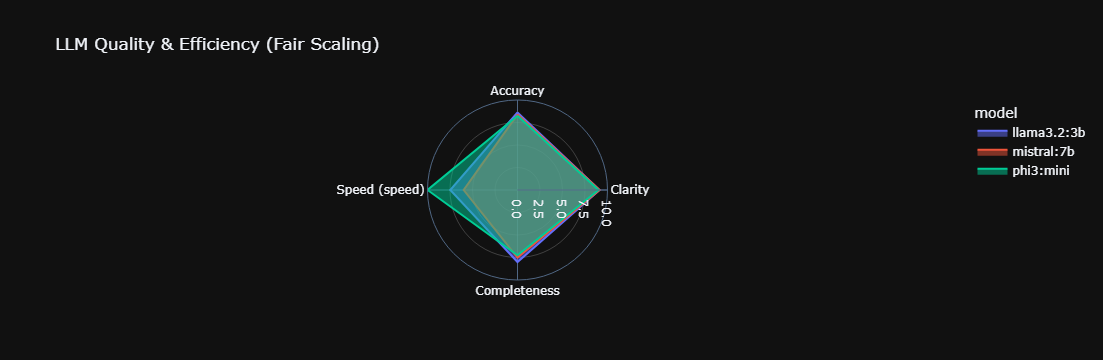

In [16]:
import plotly.express as px

# 1. Calculate Efficiency Score (The "Fair" Way)
# Score = (Min Latency / Current Latency) * 10
min_latency = leaderboard['avg_latency_ms'].min()

leaderboard['speed_efficiency'] = leaderboard['avg_latency_ms'].apply(
    lambda x: round((min_latency / x) * 10, 2)
)

# 2. Melt for the Radar Chart
metrics = ["avg_accuracy", "avg_clarity", "avg_completeness", "speed_efficiency"]
melted_df = leaderboard.melt(
    id_vars=["model"], 
    value_vars=metrics,
    var_name="Metric", 
    value_name="Score"
)

# Clean up Metric names for the display
melted_df["Metric"] = melted_df["Metric"].str.replace("avg_", "").str.replace("_efficiency", " (Speed)").str.capitalize()

# 3. Create Radar Chart
fig_radar = px.line_polar(
    melted_df, 
    r="Score", 
    theta="Metric", 
    color="model", 
    line_close=True,
    # This ensures 2 decimals are shown when you hover over a point
    hover_data={"Score": ":.2f"}, 
    range_r=[0, 10],
    template="plotly_dark",
    title="LLM Quality & Efficiency (Fair Scaling)"
)

# 4. Customizing the Axis for Decimals
fig_radar.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 10],
            tickvals=[0, 2.5, 5, 7.5, 10], # Specific decimal points on the grid
            tickformat=".1f",              # Forces 1 decimal place (e.g., 7.5)
            gridcolor="rgba(255, 255, 255, 0.2)"
        )
    ),
    showlegend=True
)

fig_radar.update_traces(fill='toself', marker=dict(size=8))
fig_radar.show()


---
## Cell 11 — Quality Breakdown Chart

Shows accuracy, clarity, and completeness separately for each model.
A model might be accurate but unclear, or complete but inaccurate.

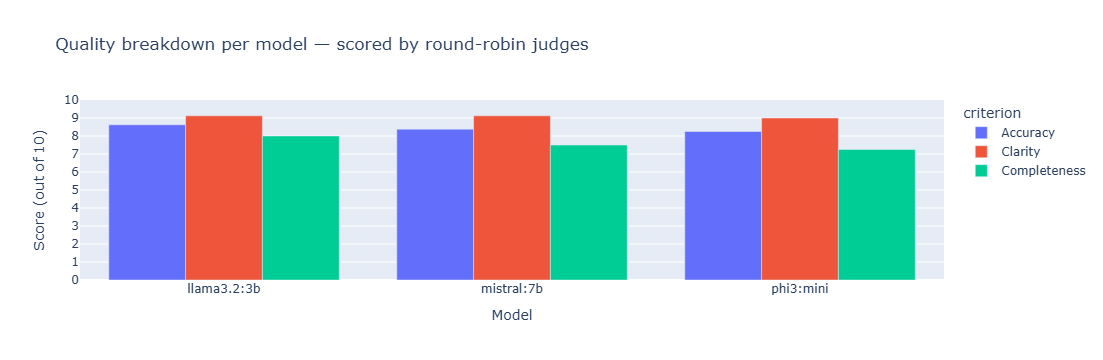

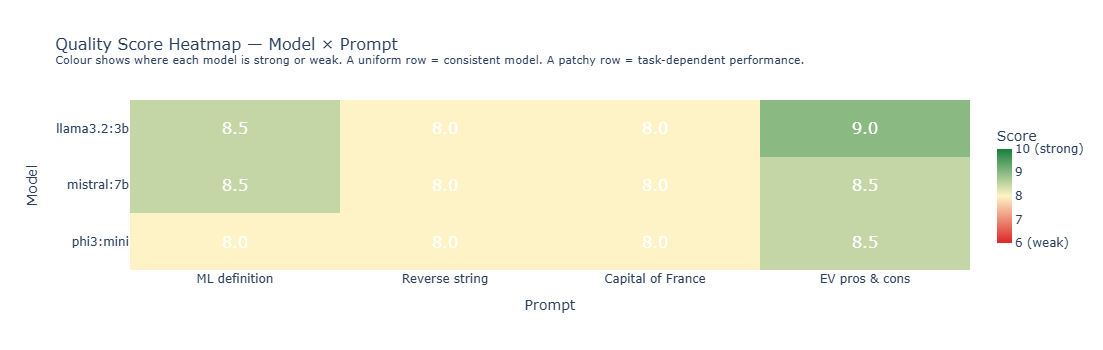

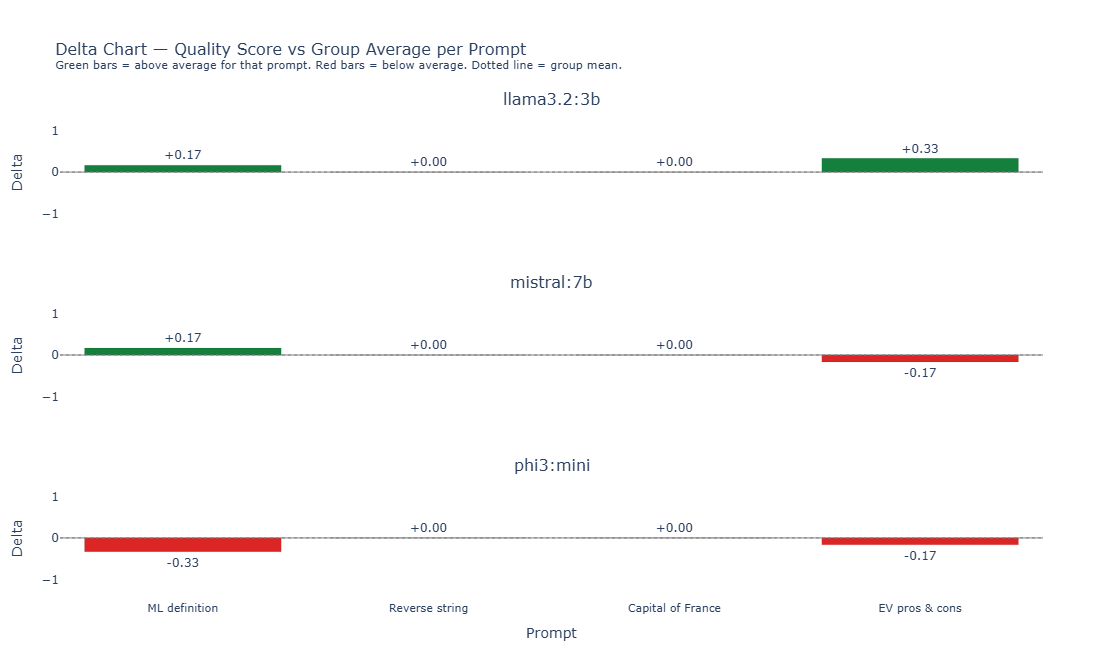

In [22]:
melted = leaderboard.melt(
    id_vars=["model"],
    value_vars=["avg_accuracy", "avg_clarity", "avg_completeness"],
    var_name="criterion",
    value_name="score"
)
# Clean up labels: avg_accuracy → Accuracy
melted["criterion"] = melted["criterion"].str.replace("avg_", "").str.capitalize()

fig2 = px.bar(
    melted,
    x="model", y="score", color="criterion",
    barmode="group",
    range_y=[0, 10],
    title="Quality breakdown per model — scored by round-robin judges",
    labels={"score": "Score (out of 10)", "model": "Model"}
)
fig2.update_layout(yaxis=dict(tickmode="linear", tick0=0, dtick=1))
fig2.show()

# ── Heatmap: Quality score by model × prompt ──────────────────────────────
import plotly.graph_objects as go
import numpy as np

# Pull the data from your existing df_judge_clean DataFrame
# This pivots it so rows = models, columns = prompts
heatmap_data = df_judge_clean.groupby(
    ["evaluated_model", "prompt_short"]
)["overall_score"].mean().round(2).reset_index()

pivot = heatmap_data.pivot(
    index="evaluated_model",
    columns="prompt_short",
    values="overall_score"
)

# Short labels so they fit on the chart cleanly
prompt_labels = [
    "ML definition",
    "Reverse string",
    "Capital of France",
    "EV pros & cons"
]

model_labels = pivot.index.tolist()
z_values = pivot.values.tolist()

# Build the heatmap
fig_heatmap = go.Figure(data=go.Heatmap(
    z=z_values,
    x=prompt_labels,
    y=model_labels,
    colorscale=[
        [0.0,  "#DC2626"],   # red   = low score
        [0.5,  "#FEF3C7"],   # amber = mid
        [1.0,  "#15803D"],   # green = high score
    ],
    zmin=6,    # set floor at 6 so colour contrast is meaningful
    zmax=10,   # ceiling at 10
    text=[[f"{v:.1f}" for v in row] for row in z_values],
    texttemplate="%{text}",
    textfont={"size": 16, "color": "white"},
    showscale=True,
    colorbar=dict(
        title="Score",
        tickvals=[6, 7, 8, 9, 10],
        ticktext=["6 (weak)", "7", "8", "9", "10 (strong)"],
        thickness=15,
        len=0.8
    )
))

fig_heatmap.update_layout(
    title=dict(
        text="Quality Score Heatmap — Model × Prompt<br>"
             "<sup>Colour shows where each model is strong or weak. "
             "A uniform row = consistent model. A patchy row = task-dependent performance.</sup>",
        font=dict(size=16)
    ),
    xaxis=dict(
        title="Prompt",
        tickfont=dict(size=12),
        side="bottom"
    ),
    yaxis=dict(
        title="Model",
        tickfont=dict(size=12),
        autorange="reversed"   # top model at the top
    ),
    height=350,
    margin=dict(l=130, r=80, t=100, b=80),
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig_heatmap.show()


# ── Delta Chart: Score deviation from group average ───────────────────────

# Step 1: calculate the average score for each prompt across all models
# This is the "group average" baseline we subtract from
prompt_averages = (
    df_judge_clean
    .groupby("prompt_short")["overall_score"]
    .mean()
    .rename("prompt_avg")
)

# Step 2: for each (model, prompt) pair, calculate the delta
delta_data = (
    df_judge_clean
    .groupby(["evaluated_model", "prompt_short"])["overall_score"]
    .mean()
    .reset_index()
    .merge(prompt_averages, on="prompt_short")
)

delta_data["delta"] = (
    delta_data["overall_score"] - delta_data["prompt_avg"]
).round(3)

# Short prompt labels to match heatmap
label_map = {
    p: s for p, s in zip(
        delta_data["prompt_short"].unique(),
        ["ML definition", "Reverse string", "Capital of France", "EV pros & cons"]
    )
}
delta_data["prompt_label"] = delta_data["prompt_short"].map(label_map)

# Step 3: assign colours — green if above average, red if below
delta_data["bar_color"] = delta_data["delta"].apply(
    lambda d: "#15803D" if d >= 0 else "#DC2626"
)

models = delta_data["evaluated_model"].unique()

# One subplot row per model so you can read each model's profile clearly
from plotly.subplots import make_subplots

fig_delta = make_subplots(
    rows=len(models), cols=1,
    shared_xaxes=True,
    subplot_titles=[f"{m}" for m in models],
    vertical_spacing=0.12
)

for i, model in enumerate(models, start=1):
    model_data = delta_data[delta_data["evaluated_model"] == model]

    fig_delta.add_trace(
        go.Bar(
            x=model_data["prompt_label"],
            y=model_data["delta"],
            marker_color=model_data["bar_color"].tolist(),
            marker_line_color="rgba(0,0,0,0.15)",
            marker_line_width=0.5,
            text=[
                f"+{d:.2f}" if d >= 0 else f"{d:.2f}"
                for d in model_data["delta"]
            ],
            textposition="outside",
            textfont=dict(size=12),
            showlegend=False,
            name=model
        ),
        row=i, col=1
    )

    # Zero reference line — the "average" baseline
    fig_delta.add_hline(
        y=0,
        line_dash="dot",
        line_color="gray",
        line_width=1,
        row=i, col=1
    )

fig_delta.update_layout(
    title=dict(
        text="Delta Chart — Quality Score vs Group Average per Prompt<br>"
             "<sup>Green bars = above average for that prompt. "
             "Red bars = below average. Dotted line = group mean.</sup>",
        font=dict(size=16)
    ),
    height=180 * len(models) + 120,
    margin=dict(l=60, r=60, t=110, b=60),
    plot_bgcolor="white",
    paper_bgcolor="white"
)

# Consistent Y axis across all subplots so models are fairly comparable
fig_delta.update_yaxes(
    zeroline=True,
    zerolinecolor="gray",
    zerolinewidth=1,
    range=[-1.5, 1.5],    # adjust if your deltas go wider
    tickformat="+.1f",    # shows + sign on positive values
    title_text="Delta"
)

fig_delta.update_xaxes(
    tickfont=dict(size=11),
    row=len(models), col=1,
    title_text="Prompt"
)

fig_delta.show()

---
## Cell 12 — Full Judgment Log

Read every individual judgment — who judged who, what score they gave,
and why. Useful for spotting disagreements between judges.

In [13]:
print("FULL JUDGMENT LOG\n")
print(f"{'Evaluated':20s}  {'Judge':20s}  {'Acc':>4} {'Cla':>4} {'Com':>4} {'Ovr':>4}  Reasoning")
print("-" * 100)

for _, row in df_judge.iterrows():
    status = "" if row["overall_score"] > 0 else "[FAILED PARSE]"
    print(
        f"{row['evaluated_model']:20s}  "
        f"{row['judge_model']:20s}  "
        f"{row['accuracy_score']:>4}  "
        f"{row['clarity_score']:>4}  "
        f"{row['completeness_score']:>4}  "
        f"{row['overall_score']:>4}  "
        f"{status}{str(row['judge_reasoning'])[:60]}"
    )

print()
print("TIP: If two judges disagree by 3+ points on the same response,")
print("that model may not be a reliable evaluator for that type of question.")

FULL JUDGMENT LOG

Evaluated             Judge                  Acc  Cla  Com  Ovr  Reasoning
----------------------------------------------------------------------------------------------------
llama3.2:3b           mistral:7b               8     9     7     8  The response accurately defines machine learning as a subset
llama3.2:3b           phi3:mini                9    10     9     9  The response accurately and clearly explains machine learnin
mistral:7b            llama3.2:3b              8     9     7     8  The response accurately defines machine learning but could b
mistral:7b            phi3:mini                9    10     8     9  The response accurately and clearly explains machine learnin
phi3:mini             llama3.2:3b              8     9     7     8  The response accurately conveys the basic concept of machine
phi3:mini             mistral:7b               8     9     7     8  The response accurately defines machine learning but could h
llama3.2:3b           mistral:7

---
## Cell 13 — Export Results

In [ ]:
df_final.to_csv("benchmark_final.csv",     index=False)
df_judge.to_csv("all_judgments.csv",        index=False)
leaderboard.to_csv("leaderboard.csv",       index=False)

print("Saved 3 files:")
print("  benchmark_final.csv  — speed + quality per model per prompt")
print("  all_judgments.csv    — every individual judgment with reasoning")
print("  leaderboard.csv      — final averaged scores per model")